## NHS Referral to Treatment (RTT) Waiting Time Predictions
In this notebook, I created a machine learning model to predict the number of weeks a patient would be on the waiting list based on their provider and specialty.

My initial plan was to create a classification model that would only predict whether or not a patient would be a long wait (waiting over a year), but I decided to switch to a linear regression model instead because I believed it would be more practical. A patient can enter a provider and specialty into the "predict_wait_time" function at the bottom of the notebook to get an estimate of how many weeks they would have to wait before receiving treatment.

The model and function was then exported to be used in a live web app.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error

import pickle

## Data Analysis
I performed some initial analysis to discover the overall percentage of patients waiting over a year (>52 weeks) as well as the percentages based on provider and specialty.

In [2]:
# Read in data
df = pd.read_csv("rtt.csv")
df.head()

,provider,specialty,weeks_waiting,patient_count
0,FULWOOD HALL HOSPITAL,Trauma and Orthopaedic Service,50,0
1,FULWOOD HALL HOSPITAL,Trauma and Orthopaedic Service,51,0
2,FULWOOD HALL HOSPITAL,Trauma and Orthopaedic Service,52,0
3,FULWOOD HALL HOSPITAL,Trauma and Orthopaedic Service,53,0
4,FULWOOD HALL HOSPITAL,Trauma and Orthopaedic Service,54,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5452125 entries, 0 to 5452124
Data columns (total 4 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   provider       object
 1   specialty      object
 2   weeks_waiting  int64 
 3   patient_count  int64 
dtypes: int64(2), object(2)
memory usage: 166.4+ MB


In [4]:
df.describe()

,weeks_waiting,patient_count
count,5.452125e+06,5.452125e+06
mean,5.300000e+01,1.318326e+00
std,3.030952e+01,1.089520e+01
min,1.000000e+00,0.000000e+00
25%,2.700000e+01,0.000000e+00
50%,5.300000e+01,0.000000e+00
75%,7.900000e+01,0.000000e+00
max,1.050000e+02,1.046000e+03


In [5]:
# Create long wait column for patients waiting more than a year
df["long_wait"] = (df["weeks_waiting"] > 52).astype(int)
# 1 = True (cells with patients waiting over a year) 2 = False (cells with patients waiting less than a year)
df["long_wait"].value_counts()



long_wait
1    2752025
0    2700100
Name: count, dtype: int64

In [6]:
# Find percentage of patients waiting over a year
(df["patient_count"] * df["long_wait"]).sum() / df["patient_count"].sum()

np.float64(0.019104920824906294)

In [7]:
# Percentage of patients waiting over a year by specialty
specialty_long_wait = df.groupby("specialty").apply(
    lambda x: (x["patient_count"] * x["long_wait"]).sum() / x["patient_count"].sum()
).sort_values(ascending=False)

# Top 10 specialties with patients waiting over a year (by percentage)
specialty_long_wait.head(10)

/var/folders/z8/rcsh9fvj18j0snmm09x520s80000gn/T/ipykernel_30674/3524414610.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  specialty_long_wait = df.groupby("specialty").apply(


specialty
Plastic Surgery Service           0.032952
Oral Surgery Service              0.031475
Trauma and Orthopaedic Service    0.029642
Ear Nose and Throat Service       0.027370
Gynaecology Service               0.026017
General Surgery Service           0.023173
Urology Service                   0.020146
Other - Surgical Services         0.019017
Neurosurgical Service             0.018233
Neurology Service                 0.016976
dtype: float64

In [8]:
# Percentage of patients waiting over a year by provider
provider_long_wait = df.groupby("provider").apply(
    lambda x: (x["patient_count"] * x["long_wait"]).sum() / x["patient_count"].sum()
).sort_values(ascending=False)

# Top 10 providers with patients waiting over a year (by percentage)
provider_long_wait.head(10)

/var/folders/z8/rcsh9fvj18j0snmm09x520s80000gn/T/ipykernel_30674/1827594638.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  provider_long_wait = df.groupby("provider").apply(


provider
PIONEER HEALTHCARE LIMITED                                                   0.365354
NUFFIELD HEALTH, TUNBRIDGE WELLS HOSPITAL                                    0.348148
NUFFIELD HEALTH PARKSIDE HOSPITAL                                            0.247911
NUFFIELD HEALTH, EXETER HOSPITAL                                             0.232906
OXLEAS NHS FOUNDATION TRUST                                                  0.177995
NUFFIELD HEALTH, GUILDFORD HOSPITAL                                          0.169154
THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HOSPITAL NHS FOUNDATION TRUST    0.125374
NUFFIELD HEALTH, CHELTENHAM HOSPITAL                                         0.113924
NUFFIELD HEALTH, WOKING HOSPITAL                                             0.102459
NUFFIELD HEALTH, BRIGHTON HOSPITAL                                           0.080552
dtype: float64

## Initial Approach: Classification Model

My initial plan was to create a logistic regression model to predict whether or not a patient would be a long wait (on the waiting list for over 1 year or 52 weeks)

However, due to severe class imbalance in the dataset (there were only about 2% of long waits), the model struggled with precision and produced many false positives.

As a result, I shifted to a regression approach to directly predict waiting time in weeks, which I beleive provides more practical insights and can be used as tool to help patients and clinical/management staff.

In [9]:
# Prepare data for modelling

# Remove rows where patient count is 0
df_model = df[df["patient_count"] > 0]

# Make data model ready by making one row represent one patient
df_expanded = df_model.loc[df_model.index.repeat(df_model["patient_count"])]
df_expanded = df_expanded.drop(columns=["patient_count"])

# Drop weeks waiting column so model learns to predict long waits based on provider and specialty
df_expanded = df_expanded.drop(columns=["weeks_waiting"])

# Convert provider categories to numbers
provider_dummies = pd.get_dummies(df_expanded["provider"], prefix="provider", drop_first=True)
df_expanded = pd.concat([df_expanded, provider_dummies], axis=1)

specialty_dummies = pd.get_dummies(df_expanded["specialty"], prefix="specialty", drop_first=True)
df_expanded = pd.concat([df_expanded, specialty_dummies], axis=1)

df_expanded = df_expanded.drop(columns=["provider", "specialty"])
df_expanded = df_expanded.astype(int)

# Use a random sample of this data because the dataframe is too long (7 million+ rows) and causes system to crash
# Use 200,000 rows (patients) as sample size
df_sample = df_expanded.sample(n=200000, random_state=42) 


In [10]:
# Create model

X = df_sample.drop(columns=["long_wait"]) # Use providers and specialties as inputs
y = df_sample["long_wait"] # Use long wait as output

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [11]:
# Make predictions
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

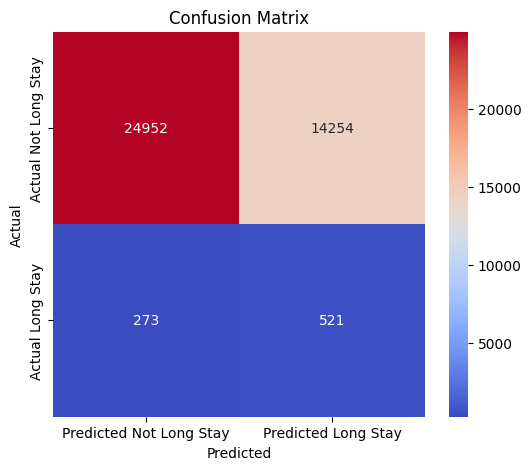

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Predicted Not Long Stay", "Predicted Long Stay"], 
    yticklabels=["Actual Not Long Stay", "Actual Long Stay"]
    )
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.64      0.77     39206
           1       0.04      0.66      0.07       794

    accuracy                           0.64     40000
   macro avg       0.51      0.65      0.42     40000
weighted avg       0.97      0.64      0.76     40000



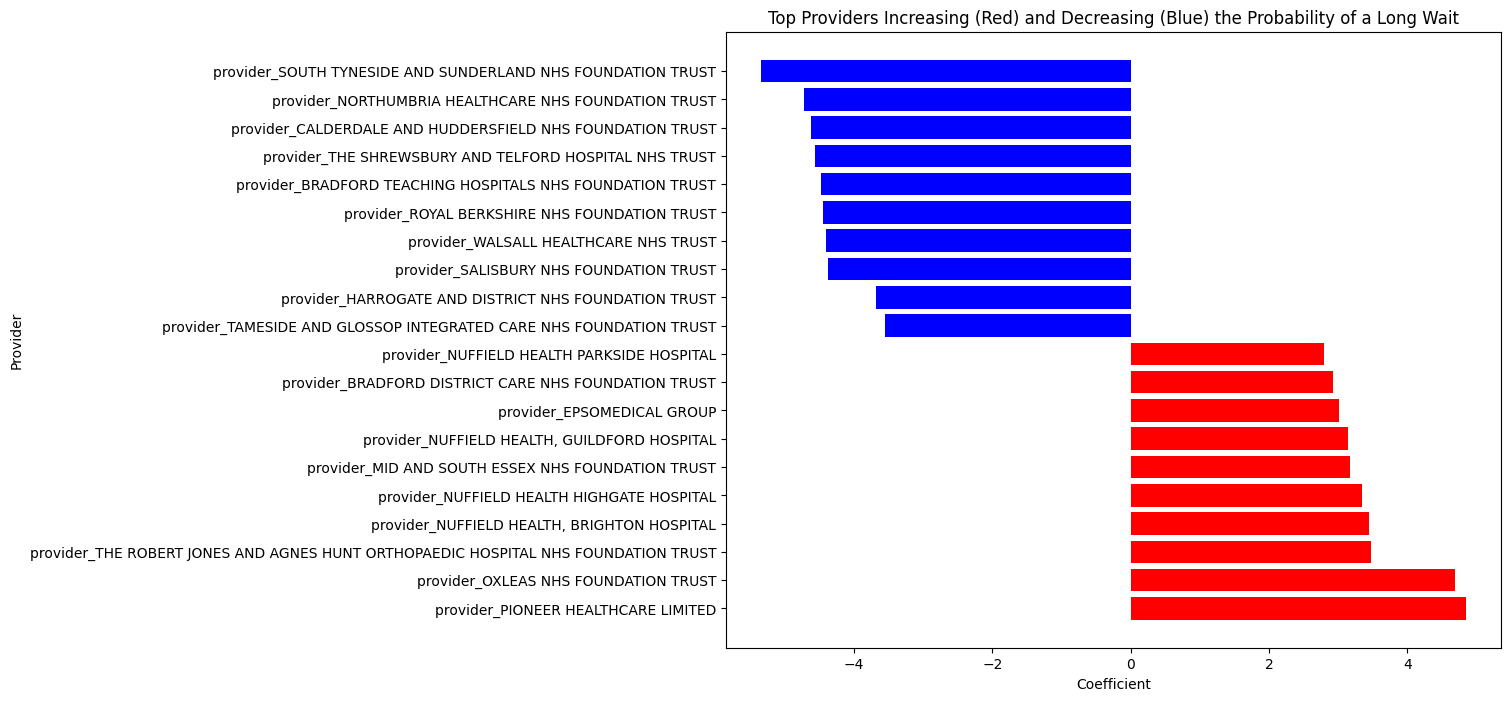

In [14]:
features = X_train.columns
coefs = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': coefs
}).sort_values(by=["coefficient"], ascending=False)

# Top 10 providers/specialties increasing the probability of a long wait
top_inc = coef_df.head(10)

# Top 10 providers/specialties decreasing the probability of a long wait
top_dec = coef_df.tail(10)

top_features = pd.concat([top_inc, top_dec])

plt.figure(figsize=(10,8))
plt.barh(top_features["feature"], top_features["coefficient"], color=['red' if x > 0 else 'blue' for x in top_features["coefficient"]])
plt.ylabel("Provider")
plt.xlabel("Coefficient")
plt.title("Top Providers Increasing (Red) and Decreasing (Blue) the Probability of a Long Wait")
plt.show()


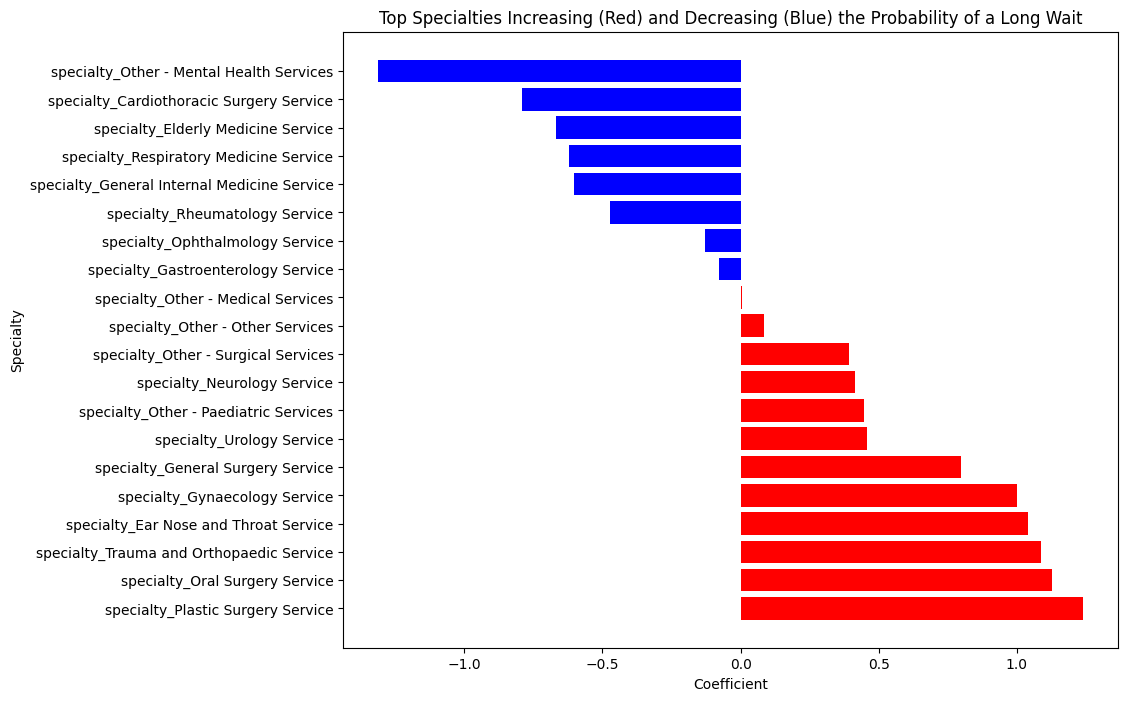

In [15]:
specialty_coef_df = coef_df[coef_df["feature"].str.startswith("specialty")].sort_values(by=["coefficient"], ascending=False)

# Top 10 specialties increasing the probability of a long wait
top_inc = specialty_coef_df.head(10)

# Top 10 specialties decreasing the probability of a long wait
top_dec = specialty_coef_df.tail(10)

top_features = pd.concat([top_inc, top_dec])

plt.figure(figsize=(10,8))
plt.barh(top_features["feature"], top_features["coefficient"], color=['red' if x > 0 else 'blue' for x in top_features["coefficient"]])
plt.ylabel("Specialty")
plt.xlabel("Coefficient")
plt.title("Top Specialties Increasing (Red) and Decreasing (Blue) the Probability of a Long Wait")
plt.show()

## Revised Approach: Regression Model
I created a linear regression model to predict the amount of weeks a patient would spend on the waiting list based on provider and specialty.

The mean absolute error (MAE) was approximately 11 weeks.

In [28]:
# Dataframe for regression model

# Drop rows with 0 patients waiting
df_reg = df[df["patient_count"] > 0]

# Drop long wait column
df_reg = df_reg.drop(columns=["long_wait"])

# Turn category (provider and specialty) columns into numbers so the model can learn from them
df_encoded = pd.get_dummies(df_reg, columns=["provider", "specialty"], drop_first=True, dtype=int)
df_encoded.shape



(525064, 537)

In [29]:
# Create model

# Inputs
X = df_encoded.drop(columns=["patient_count", "weeks_waiting"])

# Weights
weights = df_encoded["patient_count"]

# Outputs
y = df_encoded["weeks_waiting"]

# Split data into training and testing set
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, weights, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train, sample_weight=w_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# Make predictions
y_pred = model.predict(X_test)

# Test model accuracy
mae = mean_absolute_error(y_test, y_pred, sample_weight=w_test)
print(f"Mean Absolute Error: {mae}")


Mean Absolute Error: 10.978588718462216


## Wait Time Prediction Function
The code block below shows a function that can be used with the model to predict the wait time in weeks based on specialty and provider.

It was tested with provider "ACES BIRMINGHAM" and specialty "Urology Service".

In [31]:
# Function to predict wait time (in weeks) based on specialty and provider

def predict_wait_time(provider, specialty):
    # Create a dataframe with one row and fill it withe zeros
    feature_columns = X_train.columns
    row = pd.DataFrame(np.zeros((1, len(feature_columns))), columns=feature_columns)

    # Set correct columns to 1 for the correct provider and specialty
    provider_column = "provider_" + provider
    specialty_column = "specialty_" + specialty
    
    if provider_column in row.columns:
        row[provider_column] = 1
    else: 
        print(f"Provider '{provider}' not found")

    if specialty_column in row.columns:
        row[specialty_column] = 1
    else:
        print(f"Specialty '{specialty}' not found")
    
    #  Use model to predict wait time
    prediction = model.predict(row)[0]
    return round(prediction, 2)

predict_wait_time("ACES BIRMINGHAM", "Urology Service")


np.float64(13.93)

## Exports for Web App
The model and feature columns were exported to be used along with the "predict_wait_time" function in a Streamlit web application.

The names of the providers and specialties in the dataset were also exported in order to be used in dropdown selection menus within the app.

In [32]:
# Save model and input features
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("feature_columns.pkl", "wb") as file:
    pickle.dump(X_train.columns, file)

In [33]:
# Save provider and specialty names for app
providers = sorted(df["provider"].unique())
specialties = sorted(df["specialty"].unique())

with open("providers.pkl", "wb") as file:
    pickle.dump(providers, file)

with open("specialties.pkl", "wb") as file:
    pickle.dump(specialties, file)

